### 0. Importing

In [ ]:
#%pip install statsmodels
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv('PartI_dev.csv')
print(df.Y.value_counts()) # We have 11 classes 
print(df.shape)
# =====================================================================
# DATA CLEANING/EXPLORATION
#
# =====================================================================
# Descriptive stats
print(df.describe())
print(df.info()) #All float values. No need for encoding.
print(df.isnull().sum()) # All defined values. No missing data.


Y
1     4255
2     4255
3     4255
4     4255
5     4255
6     4255
7     4255
8     4255
9     4255
10    4255
11    4255
Name: count, dtype: int64
(46805, 49)
                 X1            X2            X3            X4            X5  \
count  46805.000000  46805.000000  46805.000000  4.680500e+04  46805.000000   
mean      -0.000003      0.000002      0.000002 -1.196022e-06      0.000001   
std        0.000075      0.000057      0.000256  6.524010e-05      0.000061   
min       -0.013756     -0.003989     -0.013538 -1.277087e-02     -0.008345   
25%       -0.000023     -0.000024     -0.000112 -1.877998e-05     -0.000024   
50%       -0.000003      0.000002      0.000002 -8.788122e-07      0.000001   
75%        0.000017      0.000027      0.000116  1.681469e-05      0.000027   
max        0.005807      0.004485      0.005403  1.461591e-03      0.000840   

                 X6            X7            X8            X9           X10  \
count  4.680500e+04  46805.000000  46805.000000 

<Axes: >

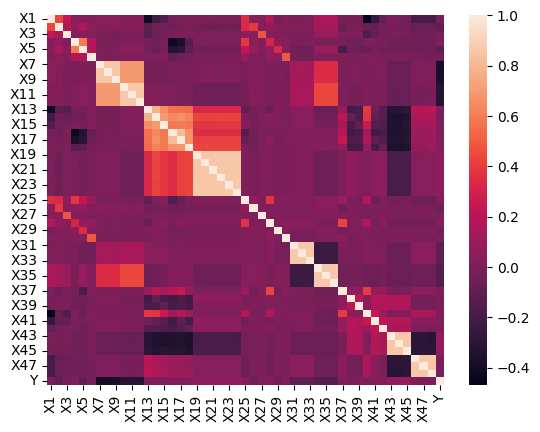

In [ ]:
# =====================================================================
# Correlation matrix
#
# =====================================================================
sns.heatmap(df.corr()) 
# Correlation matrix shows elements of multicollinearity.
# When deciding the model we gotta be careful about multicollinearity as this will affect the model's performance
# additional considerations may be needed in terms of scaling and dimensionality reduction.

### Part 0 Data Prep

In [52]:
scalar = StandardScaler()
encoder = LabelEncoder()
pca = PCA()

data = df.copy()
Y = data['Y']
Y = encoder.fit_transform(Y) # apply just to prevent any mix ups with the model. We can decode the predictions later on.
X = data.drop(columns=['Y'])
# 70/30 split for dev/test
x_dev, x_test, y_dev, y_test = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y)

X_dev_scaled = scalar.fit_transform(x_dev)
X_test_scaled = scalar.transform(x_test)

print(f"X_dev shape: {x_dev.shape}, X_test shape: {x_test.shape}")

X_dev shape: (32763, 48), X_test shape: (14042, 48)


### PART 1

## For traditional I will be using ensemble methods

Due to the high concentration of features and classes the best model to choose would be RandomForest as a baseline then move in XGBoost and or LightGBM
- Why? The overall goal is generalization and efficiency since the models we will be implementating and testing on will see a unseen data set and also will have to generalize to 11 class and 48 features. Ensemble methods are robust to noise in that they average predictions from multiple learners. Additionally we want to prevent extensive hyperparameter tuning and have an easy way to deal with the level of multicolinearity from this data set so the procedure will be as follows

* Step 1: RandomForest hyper parameter tuning on X_Dev set -> Save results & params
* Step 2: XGBoost & LightGBM hyper parameter tuning on X_Dev Set -> Save results & params
* Step 3: Analysis 
* Step 4: Run best model on train and test set report results and possible reasons for issues.




In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

class ModelPipeline(BaseEstimator, ClassifierMixin):
    def __init__(self, model, n_components=None, scale=True):
        self.model = model
        self.n_components = n_components
        self.scale = scale
        self.scaler = None
        self.pca = None

    def fit(self, X, y):
        X_proc = X.copy()
        if self.scale:
            self.scaler = StandardScaler()
            X_proc = self.scaler.fit_transform(X_proc)
        if self.n_components is not None:
            self.pca = PCA(n_components=self.n_components)
            X_proc = self.pca.fit_transform(X_proc)
        self.model.fit(X_proc, y)
        return self

    def transform(self, X):
        X_proc = X.copy()
        if self.scale and self.scaler is not None:
            X_proc = self.scaler.transform(X_proc)
        if self.n_components is not None and self.pca is not None:
            X_proc = self.pca.transform(X_proc)
        return X_proc

    def transform_only(self, X):
        """
        Transform data using scaler and PCA fit on training data.
        Use this for test/validation data to avoid data leakage.
        """
        return self.transform(X)

    def predict(self, X):
        X_proc = self.transform_only(X)
        return self.model.predict(X_proc)

    def predict_proba(self, X):
        X_proc = self.transform_only(X)
        return self.model.predict_proba(X_proc)


###  1.1 Feature Engineering then measuring correlation


Dropping 'X47' with VIF: 945727.70
Dropping 'X44' with VIF: 705482.34
Dropping 'X46' with VIF: 703799.80
Dropping 'X45' with VIF: 538417.48
Dropping 'X43' with VIF: 75217.06
Dropping 'X24' with VIF: 93.51
Dropping 'X23' with VIF: 89.07
Dropping 'X22' with VIF: 84.26
Dropping 'X21' with VIF: 76.04
Dropping 'X20' with VIF: 61.00
Dropping 'X48' with VIF: 24.80
Dropping 'X16' with VIF: 18.09
Dropping 'X19' with VIF: 16.52
Dropping 'X13' with VIF: 12.91
Dropping 'X17' with VIF: 10.46
Remaining features after removing high VIF features:
Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
       'X12', 'X14', 'X15', 'X18', 'X25', 'X26', 'X27', 'X28', 'X29', 'X30',
       'X31', 'X32', 'X33', 'X34', 'X35', 'X36', 'X37', 'X38', 'X39', 'X40',
       'X41', 'X42', 'Y'],
      dtype='str')


<Axes: >

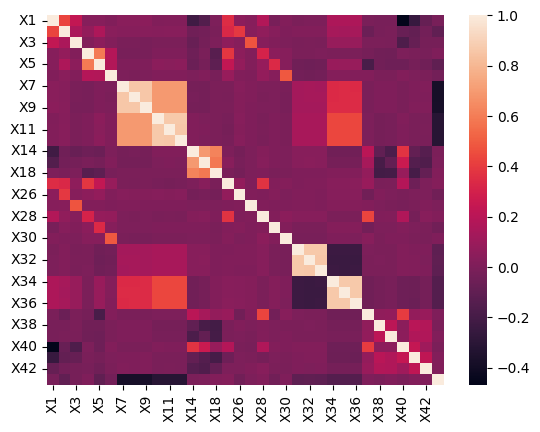

In [9]:

# Based on the heatmap, we can see that there are some features that have
# high correlation with one another, we will need to worry about multicollinearity when we build our model. 
# We can also see that there are some features that have low correlation with the target variable, 
# we may want to consider dropping those features when we build our model.

# PCA will be needed. Now we can use regularization but it will not be as effective as PCA.
# Due to the nature of the correlation matrix, we will need to use PCA

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data["feature"] = df.columns
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif_data

removed_table = df.copy()
threshold = 10
while True:
    vif_data = calculate_vif(removed_table)
    max_vif = vif_data['VIF'].max()
    if max_vif > threshold:
        drop_feature = vif_data.sort_values('VIF', ascending=False)['feature'].iloc[0]
        print(f"Dropping '{drop_feature}' with VIF: {max_vif:.2f}")
        removed_table = removed_table.drop(columns=[drop_feature])
    else:
        break

print("Remaining features after removing high VIF features:")
print(removed_table.columns)
sns.heatmap(removed_table.corr())

In [10]:
X_removal = removed_table.drop(columns=['Y'])  # Drop target if present
Y_removal = removed_table['Y']  # Target variable
X_train_removal, X_temp_removal, Y_train_removal, Y_temp_removal = train_test_split(X_removal, Y_removal, stratify=Y_removal, test_size=0.3, random_state=42)
X_val_removal, X_test_removal, Y_val_removal, Y_test_removal = train_test_split(X_temp_removal, Y_temp_removal, stratify=Y_temp_removal, test_size=0.67, random_state=42)

In [ ]:
'''scaler = StandardScaler()
#X = data.drop(columns=['Y'])  # Drop target if present
X_scaled = scaler.fit_transform(X_train_removal)
X_scaled_val = scaler.transform(X_val_removal)
X_scaled_test = scaler.transform(X_test_removal)'''
print(X_train_removal.shape, Y_train_removal.shape, X_val_removal.shape, Y_val_removal.shape, X_test_removal.shape, Y_test_removal.shape)
pipe = ModelPipeline(
    model=RandomForestClassifier(n_estimators=100, n_jobs=-1),
)
pipe.fit(X_train_removal, Y_train_removal)

y_pred = pipe.predict(X_test_removal)
print("Number of mislabeled points out of a total %d points : %d"
      % (X_test_removal.shape[0], (Y_test_removal != y_pred).sum()))
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(Y_test_removal, y_pred))
print(classification_report(Y_test_removal, y_pred))




(32763, 33) (32763,) (4633, 33) (4633,) (9409, 33) (9409,)
Number of mislabeled points out of a total 9409 points : 2849
Accuracy: 0.6972048039111489
              precision    recall  f1-score   support

           1       0.62      0.71      0.66       855
           2       0.66      0.68      0.67       855
           3       0.64      0.71      0.67       855
           4       0.73      0.75      0.74       855
           5       0.53      0.46      0.49       856
           6       0.54      0.44      0.48       855
           7       0.96      0.97      0.97       856
           8       0.63      0.62      0.62       856
           9       0.64      0.66      0.65       856
          10       0.69      0.68      0.68       855
          11       1.00      1.00      1.00       855

    accuracy                           0.70      9409
   macro avg       0.69      0.70      0.69      9409
weighted avg       0.69      0.70      0.69      9409



AttributeError: 'RandomForestClassifier' object has no attribute 'coef_'

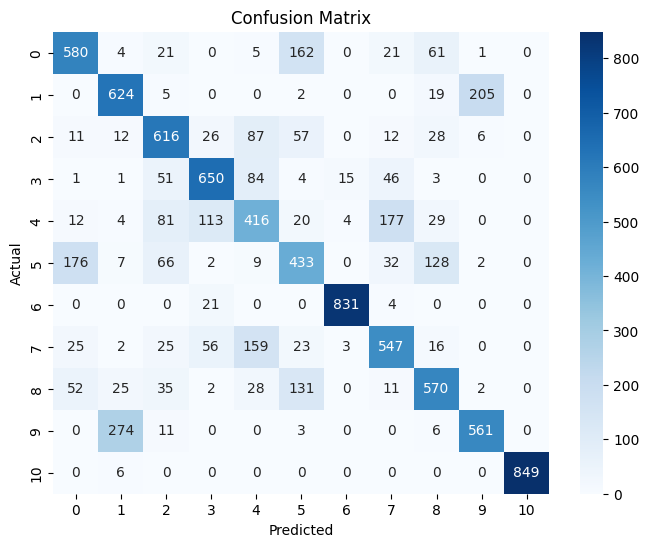

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test_removal, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Upon further analysis

Will be moving from simply just dropping features cause the removal hurts performance so will try applying L1 or L2 regularization to reduce features. Mainly L1


In [35]:
# =====================================================================
# Determine how many components to use in PCA when building our model. 
# We want to find the number of components that explain at least 95% of the variance in the data.
# =====================================================================
X = df.drop(columns=['Y'])  # Drop target if present
encoder = LabelEncoder()
Y = df['Y']  # Target variable
Y = encoder.fit_transform(Y)  # Encode target variable
# 70/20/10 split for train/test/validation

x_train, x_temp, y_train, y_temp = train_test_split(X, Y, stratify=Y, test_size=0.3, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, stratify=y_temp, test_size=0.67, random_state=42)

print(x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape)

(32763, 48) (32763,) (4633, 48) (4633,) (9409, 48) (9409,)


In [ ]:


# Example classifiers for multiclass
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(kernel='rbf', probability=True, decision_function_shape='ovr'),
    'Random Forest': RandomForestClassifier(n_estimators=100, n_jobs=-1),
    'Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

results = {}

for name, clf in classifiers.items():
    print(f'\n=== {name} ===')
    if name == 'Random Forest':
        pipe = ModelPipeline(model=clf, scale=False)
    else:
        pipe = ModelPipeline(model=clf, n_components=0.95, scale=True)
    pipe.fit(x_train, y_train)
    y_pred = pipe.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    print(f'Accuracy: {acc:.4f}')
    print(classification_report(y_test, y_pred))
    results[name] = acc

print("\nSummary of Accuracies:")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")





=== Logistic Regression ===
Accuracy: 0.6787
              precision    recall  f1-score   support

           0       0.62      0.67      0.64       855
           1       0.68      0.67      0.68       855
           2       0.63      0.67      0.65       855
           3       0.68      0.71      0.69       855
           4       0.48      0.41      0.44       856
           5       0.47      0.43      0.45       855
           6       0.97      0.96      0.96       856
           7       0.60      0.63      0.61       856
           8       0.61      0.62      0.62       856
           9       0.69      0.69      0.69       855
          10       1.00      1.00      1.00       855

    accuracy                           0.68      9409
   macro avg       0.68      0.68      0.68      9409
weighted avg       0.68      0.68      0.68      9409


=== SVM ===


KeyboardInterrupt: 

In [34]:

pipe = ModelPipeline(model=LogisticRegression(max_iter=1000, penalty='l2', C=2), scale=True)
pipe.fit(x_train, y_train)
#x_test_transformed = pipe.transform_only(x_test)  # Use this for test/validation data to avoid data leakage
# Assuming your features are in a DataFrame x_test
#x_test_transformed = pd.DataFrame(x_test_transformed, columns=[f'PC{i+1}' for i in range(x_test_transformed.shape[1])])
coefs = pd.DataFrame(pipe.model.coef_, columns=x_test.columns, index=pipe.model.classes_)
print(coefs.T)  # Features as rows, classes as columns
y_pred = pipe.predict(x_test)
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.4f}')
print(classification_report(y_test, y_pred))

c:\Users\tjmel\OneDrive\Desktop\AML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


           0         1         2         3         4         5         6   \
X1   0.087540 -0.018745  0.074437  0.086087 -0.237887  0.284872  0.075878   
X2   0.265340  0.304779  0.344264 -0.492119 -0.515265  0.390207  0.500486   
X3   0.143218  0.083243  0.043370 -0.247517 -0.214024  0.136742  0.313770   
X4  -0.033360 -0.222559 -0.177405  0.028339  0.036507 -0.344977  0.528777   
X5   0.690673  0.287632  0.537630 -0.842392 -0.750573  0.473342  0.968848   
X6   0.141831  0.067792  0.067920 -0.128826 -0.130858  0.171158  0.183003   
X7   2.260901 -3.729869  0.071731  0.741523  1.602158  1.034933  3.971516   
X8   2.183337 -3.793438  0.215755  0.782408  1.618293  1.012280  4.155251   
X9   2.247313 -3.723454 -0.004384  0.608228  1.448991  1.057109  4.103105   
X10 -2.603011 -2.080029  1.141521  3.618597  1.613525 -1.812880  6.378271   
X11 -2.725017 -1.812364  1.051404  3.655940  1.426337 -1.804394  6.492094   
X12 -2.726218 -1.897891  1.126852  3.608374  1.647312 -1.825752  6.373390   

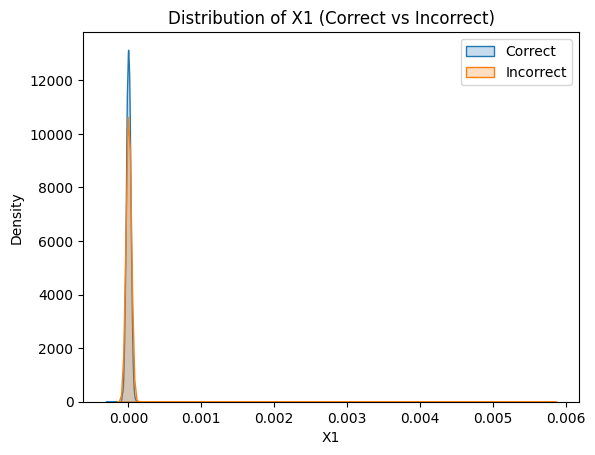

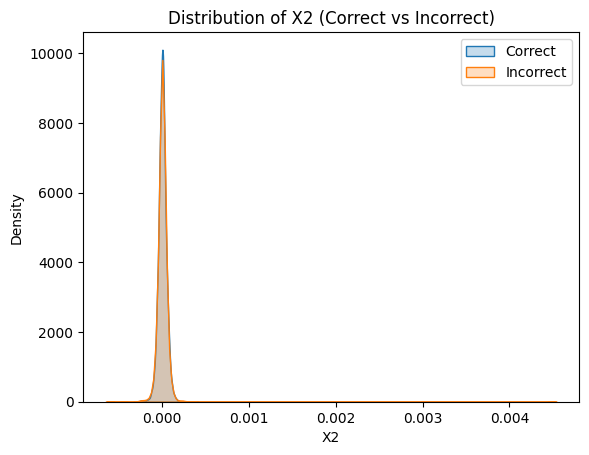

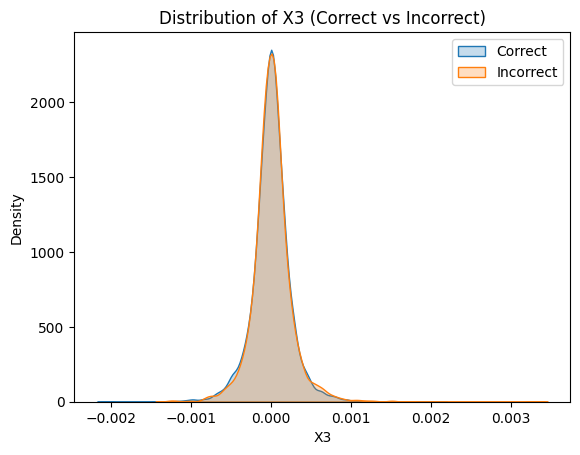

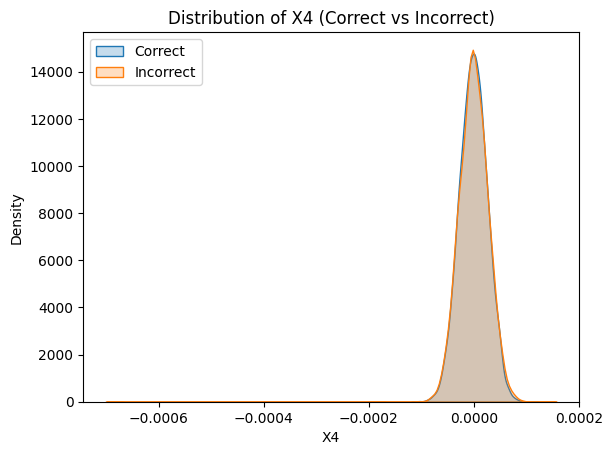

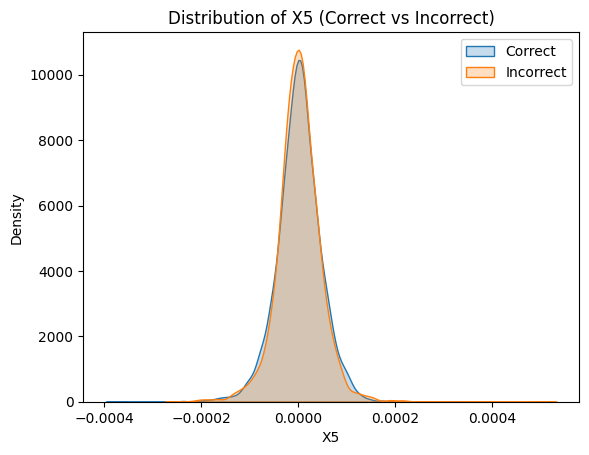

In [27]:
import numpy as np
wrong = y_test != y_pred
for col in x_test.columns[:5]:  # Check first 5 features
    plt.figure()
    sns.kdeplot(x_test.loc[~wrong, col], label='Correct', fill=True)
    sns.kdeplot(x_test.loc[wrong, col], label='Incorrect', fill=True)
    plt.title(f'Distribution of {col} (Correct vs Incorrect)')
    plt.legend()
    plt.show()